# Week 9 — Day 2
# Serving the Model with FastAPI

## Melanoma Skin Cancer — Benign vs Malignant

**Project:** Melanoma Skin Lesion Classification  
**Sprint:** Sprint 4 — Deployment  

### Purpose

This notebook continues directly from **Week 9 Day 1**.

Day 1 prepared the validated Week 8 CNN for deployment and saved the deployment artifacts. Day 2 turns that saved model into a **FastAPI REST API**.

The API will:

1. Load the serialized Week 8 CNN.
2. Load the deployment metadata and selected threshold.
3. Accept a skin-lesion image through `POST /predict`.
4. Apply the exact serving preprocessing from Day 1.
5. Run the CNN.
6. Convert the malignant probability into **Benign / Malignant** using threshold `0.35`.
7. Return the prediction as JSON.
8. Validate requests and reject invalid inputs cleanly.
9. Provide interactive API documentation through `/docs`.



## Learning Objectives

By the end of Day 2, we will:

- Understand what model serving means.
- Build a FastAPI application around the saved CNN.
- Load the serialized model from Day 1 instead of retraining it.
- Reproduce the Week 8 preprocessing contract:
  **OpenCV → BGR to RGB → resize 128×128 → float32 → divide by 255**.
- Create a `POST /predict` endpoint.
- Use FastAPI file validation for image uploads.
- Use Pydantic models for structured request/response validation.
- Test valid and invalid requests.
- Test the API through FastAPI's automatic `/docs` interface.
- Verify the complete serving chain:

```text
Image
  ↓
FastAPI
  ↓
Validation
  ↓
Preprocessing
  ↓
Serialized CNN
  ↓
Malignant probability
  ↓
Threshold = 0.35
  ↓
Benign / Malignant
  ↓
JSON response
```


#  Day 1 Deployment Contract

Day 1 saved the following deployment contract:

| Item | Value |
|---|---|
| Input | Skin-lesion image |
| Image size | 128 × 128 |
| Channels | 3 |
| Color format | RGB |
| Preprocessing | OpenCV → BGR to RGB → resize → float32 → /255 |
| Classes | Benign = 0, Malignant = 1 |
| Reference threshold | 0.50 |
| Selected deployment threshold | **0.35** |
| Model format | Keras `.keras` |

The selected threshold is a **decision rule**, not a change to the trained CNN weights.


In [1]:
!pip -q install fastapi uvicorn python-multipart httpx


#  Imports and Configuration

The API uses:

- **FastAPI** — creates the REST API.
- **Pydantic** — validates structured data.
- **Uvicorn** — runs the FastAPI server locally.
- **TensorFlow / Keras** — loads and runs the CNN.
- **OpenCV** — performs the same image preprocessing used in Day 1.
- **NumPy** — prepares the model input.


In [2]:
from pathlib import Path
import json
import io

import cv2
import numpy as np
import tensorflow as tf

from fastapi import FastAPI, UploadFile, File, HTTPException, Form
from pydantic import BaseModel, Field

print("TensorFlow:", tf.__version__)
print("FastAPI and deployment imports loaded successfully.")


TensorFlow: 2.20.0
FastAPI and deployment imports loaded successfully.


#  Locate the Day 1 Deployment Artifacts

Day 1 saved the deployment package under:

```text
deployment_artifacts/
├── melanoma_cnn.keras
├── model_metadata.json
├── requirements.txt
└── deployment_manifest.json
```

The API will **load these artifacts**. It will not retrain the model.


In [10]:
import zipfile
from pathlib import Path

ZIP_PATH = Path("/content/deployment_artifacts.zip")
EXTRACT_DIR = Path("/content")

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("ZIP extracted successfully.")

ZIP extracted successfully.


In [13]:
import zipfile

ZIP_PATH = "/content/deployment_artifacts.zip"

with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
    print("Files inside ZIP:\n")
    for name in zip_ref.namelist():
        print("-", name)

Files inside ZIP:

- melanoma_cnn.keras
- deployment_manifest.json
- requirements.txt
- model_metadata.json


In [14]:
from pathlib import Path
import shutil
BASE_DIR = Path("/content")
ARTIFACT_DIR = BASE_DIR / "deployment_artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)
shutil.copy(
    BASE_DIR / "melanoma_cnn.keras",
    ARTIFACT_DIR / "model.keras"
)

shutil.copy(
    BASE_DIR / "model_metadata.json",
    ARTIFACT_DIR / "metadata.json"
)

shutil.copy(
    BASE_DIR / "deployment_manifest.json",
    ARTIFACT_DIR / "manifest.json"
)

shutil.copy(
    BASE_DIR / "requirements.txt",
    ARTIFACT_DIR / "requirements.txt"
)

print("Deployment artifacts prepared successfully!")

Deployment artifacts prepared successfully!


In [15]:
from pathlib import Path

ARTIFACT_DIR = Path("/content/deployment_artifacts")

print("Artifact directory exists:", ARTIFACT_DIR.exists())
print("Model exists:", (ARTIFACT_DIR / "model.keras").exists())
print("Metadata exists:", (ARTIFACT_DIR / "metadata.json").exists())
print("Manifest exists:", (ARTIFACT_DIR / "manifest.json").exists())

print("\nFiles inside deployment_artifacts:")

for file in ARTIFACT_DIR.iterdir():
    print("-", file.name)

Artifact directory exists: True
Model exists: True
Metadata exists: True
Manifest exists: True

Files inside deployment_artifacts:
- manifest.json
- metadata.json
- requirements.txt
- model.keras


#  Load the Deployment Metadata

The metadata created on Day 1 contains the model contract, class mapping, and selected threshold.

Loading this metadata avoids hard-coding deployment decisions in multiple places.


In [17]:
from pathlib import Path
import shutil

BASE_DIR = Path("/content")
ARTIFACT_DIR = BASE_DIR / "deployment_artifacts"
ARTIFACT_DIR.mkdir(exist_ok=True)
shutil.copy(
    BASE_DIR / "model_metadata.json",
    ARTIFACT_DIR / "model_metadata.json"
)

print("Metadata copied successfully.")
print("Exists:", (ARTIFACT_DIR / "model_metadata.json").exists())


Metadata copied successfully.
Exists: True


In [20]:
import json

METADATA_PATH = ARTIFACT_DIR / "model_metadata.json"

if not METADATA_PATH.exists():
    raise FileNotFoundError(
        f"Missing {METADATA_PATH}. Make sure the deployment artifacts are available."
    )

with open(METADATA_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)
IMG_SIZE = (
    metadata["input"]["height"],
    metadata["input"]["width"]
)

CHANNELS = metadata["input"]["channels"]
CLASS_TO_LABEL = metadata["classes"]
LABEL_TO_CLASS = {int(v): k for k, v in CLASS_TO_LABEL.items()}
SELECTED_THRESHOLD = float(
    metadata["decision_rule"]["selected_threshold"]
)

print("Image size:", IMG_SIZE)
print("Channels:", CHANNELS)
print("Color format:", metadata["input"]["color_format"])
print("Class mapping:", CLASS_TO_LABEL)
print("Selected threshold:", SELECTED_THRESHOLD)

Image size: (128, 128)
Channels: 3
Color format: RGB
Class mapping: {'Benign': 0, 'Malignant': 1}
Selected threshold: 0.35


#  Load the Serialized CNN

The model was serialized in Day 1 as:

```text
deployment_artifacts/melanoma_cnn.keras
```

FastAPI will load this saved model when the application starts.

This is the deployment principle:

Load the trained model — do not retrain it inside the API.


In [22]:
from pathlib import Path
import shutil

BASE_DIR = Path("/content")
ARTIFACT_DIR = BASE_DIR / "deployment_artifacts"

SOURCE_MODEL = ARTIFACT_DIR / "model.keras"
TARGET_MODEL = ARTIFACT_DIR / "melanoma_cnn.keras"

if not SOURCE_MODEL.exists():
    raise FileNotFoundError(f"Source model not found: {SOURCE_MODEL}")

shutil.copy(SOURCE_MODEL, TARGET_MODEL)

print("Model copied successfully.")
print("Target exists:", TARGET_MODEL.exists())
print("Model path:", TARGET_MODEL)


Model copied successfully.
Target exists: True
Model path: /content/deployment_artifacts/melanoma_cnn.keras


In [23]:
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Serialized model not found: {MODEL_PATH}")

model = tf.keras.models.load_model(MODEL_PATH)

print("Serialized CNN loaded successfully.")
print("Model input shape:", model.input_shape)
print("Model output shape:", model.output_shape)

expected_shape = (None, IMG_SIZE[0], IMG_SIZE[1], CHANNELS)

if tuple(model.input_shape) != expected_shape:
    raise ValueError(
        f"Unexpected model input shape: {model.input_shape}. "
        f"Expected: {expected_shape}"
    )

print("PASS: model input shape matches the Day 1 deployment contract.")

Serialized CNN loaded successfully.
Model input shape: (None, 128, 128, 3)
Model output shape: (None, 1)
PASS: model input shape matches the Day 1 deployment contract.


# Reuse the Exact Serving Preprocessing

Day 1 defined the serving preprocessing as:

```text
OpenCV read
    ↓
BGR → RGB
    ↓
Resize to 128 × 128
    ↓
float32
    ↓
pixel / 255.0
    ↓
add batch dimension
```

The API must use this same pipeline.

This prevents **training/serving skew**, where the model receives data in production that is prepared differently from the data used during training.


In [24]:
def preprocess_image_bytes(image_bytes: bytes) -> np.ndarray:
    buffer = np.frombuffer(image_bytes, dtype=np.uint8)
    image = cv2.imdecode(buffer, cv2.IMREAD_COLOR)
    if image is None:
        raise ValueError("The uploaded file is not a readable image.")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(
        image,
        IMG_SIZE,
        interpolation=cv2.INTER_AREA
    )
    image = image.astype(np.float32) / 255.0
    return np.expand_dims(image, axis=0)


print("Serving preprocessing function created.")


Serving preprocessing function created.


# Define Pydantic Schemas

The original lesson demonstrates Pydantic with numeric tabular features. Our project receives an **image file**, so FastAPI's `UploadFile` performs the file-level validation.

We also define Pydantic models for the structured prediction options and response.

The `threshold` field is constrained to the valid probability range 0 to 1.

The default is the selected Week 8 deployment threshold: **0.35**.


In [25]:
class PredictionOptions(BaseModel):
    threshold: float = Field(
        default=SELECTED_THRESHOLD,
        ge=0.0,
        le=1.0,
        description="Decision threshold for malignant probability."
    )


class PredictionResponse(BaseModel):
    filename: str
    probability_malignant: float
    threshold: float
    predicted_class: str
    predicted_label: int


print("Pydantic schemas created successfully.")


Pydantic schemas created successfully.


#  Create the FastAPI Application

Now we create the API itself.

The main endpoint will be:

POST /predict

It receives:

- `file` — the uploaded skin-lesion image.
- `threshold` — optional decision threshold, validated by Pydantic through the request form.

The API will return a structured JSON response.


In [27]:
app = FastAPI(title="Melanoma Skin Lesion Prediction API",description=("FastAPI serving layer for the Week 8 validated CNN. ""The API applies the Day 1 preprocessing contract and ""classifies an uploaded lesion as Benign or Malignant."), version="1.0.0"
)
print("FastAPI application created.")


FastAPI application created.


# Add a Health Check Endpoint

A small /health endpoint is useful for checking whether the API is running and whether the model has loaded successfully.

This is not the main assignment endpoint, but it is useful deployment practice.


In [28]:
@app.get("/health")
def health():
    return {
        "status": "ok",
        "model_loaded": model is not None,
        "selected_threshold": SELECTED_THRESHOLD
    }


print("GET /health added.")


GET /health added.


#  Implement `POST /predict`

This endpoint implements the complete prediction chain:

```text
Uploaded image
      ↓
File validation
      ↓
Decode image
      ↓
BGR → RGB
      ↓
Resize 128×128
      ↓
Normalize /255
      ↓
CNN
      ↓
Malignant probability
      ↓
Threshold
      ↓
Benign / Malignant
      ↓
JSON
```

### Decision rule

Because the positive class is **Malignant**:

```text
probability >= threshold → Malignant
probability < threshold  → Benign
```

The default threshold is **0.35**, carried from Day 1.


In [29]:
@app.post(
    "/predict",
    response_model=PredictionResponse,
    summary="Predict melanoma class from an uploaded image"
)
async def predict(
    file: UploadFile = File(..., description="Skin-lesion image"),
    threshold: float = Form(
        default=SELECTED_THRESHOLD,
        ge=0.0,
        le=1.0,
        description="Malignant decision threshold between 0 and 1."
    )
):
    if not file.filename:
        raise HTTPException(
            status_code=400,
            detail="A filename is required."
        )

    allowed_types = {
        "image/jpeg",
        "image/jpg",
        "image/png",
        "image/webp"
    }

    if file.content_type not in allowed_types:
        raise HTTPException(
            status_code=415,
            detail=(
                "Unsupported file type. Please upload a JPEG, PNG, "
                "or WEBP image."
            )
        )

    image_bytes = await file.read()

    if not image_bytes:
        raise HTTPException(
            status_code=400,
            detail="The uploaded file is empty."
        )

    try:
        x = preprocess_image_bytes(image_bytes)
    except ValueError as exc:
        raise HTTPException(
            status_code=400,
            detail=str(exc)
        )

    probability = float(
        np.asarray(model.predict(x, verbose=0)).squeeze()
    )

    predicted_label = int(probability >= threshold)
    predicted_class = LABEL_TO_CLASS[predicted_label]

    return PredictionResponse(
        filename=file.filename,
        probability_malignant=probability,
        threshold=float(threshold),
        predicted_class=predicted_class,
        predicted_label=predicted_label
    )


print("POST /predict implemented successfully.")


POST /predict implemented successfully.


#  Understand the API Response

A successful request returns JSON similar to:

```json
{
  "filename": "example.jpg",
  "probability_malignant": 0.91,
  "threshold": 0.35,
  "predicted_class": "Malignant",
  "predicted_label": 1
}
```

The exact probability will depend on the uploaded image.

### Meaning

- `probability_malignant`: the CNN's predicted probability for the malignant class.
- `threshold`: the decision threshold used for this request.
- `predicted_class`: human-readable result.
- `predicted_label`: numeric class mapping.

The model itself outputs a probability. The threshold converts that probability into the final class.


#  Test the API Without Starting a Server

Before starting Uvicorn, we can test the FastAPI application directly with FastAPI's test client.

This is useful because it checks the endpoint logic without requiring a separate terminal.

We will test:

1. A valid image.
2. An unsupported file type.
3. An invalid threshold.

For the valid-image test, provide a real melanoma test image path from the Week 8 dataset.


In [31]:
from fastapi.testclient import TestClient
client = TestClient(app)
print("FastAPI TestClient created.")


FastAPI TestClient created.


##  Select a Test Image



In [33]:
TEST_IMAGE_PATH = "/content/6331.jpg"

test_path = Path(TEST_IMAGE_PATH)

print("Test image path:", test_path)
print("Exists:", test_path.exists())

if not test_path.exists():
    print(
        "\nSet TEST_IMAGE_PATH to a valid Week 8 melanoma test image "
        "before running the valid-image test."
    )


Test image path: /content/6331.jpg
Exists: True


In [34]:
if test_path.exists():
    with open(test_path, "rb") as f:
        response = client.post(
            "/predict",
            files={
                "file": (
                    test_path.name,
                    f,
                    "image/jpeg"
                )
            }
        )

    print("Status code:", response.status_code)
    print("Response:")
    print(json.dumps(response.json(), indent=2))
else:
    print("Valid-image test skipped because TEST_IMAGE_PATH does not exist.")


Status code: 200
Response:
{
  "filename": "6331.jpg",
  "probability_malignant": 0.0007730426150374115,
  "threshold": 0.35,
  "predicted_class": "Benign",
  "predicted_label": 0
}


##  Test Invalid File Type

The API should reject a non-image upload.




In [36]:
response = client.post(
    "/predict",
    files={
        "file": (
            "text.txt",
            b"This is not an image.",
            "text/plain"
        )
    }
)

print("Status code:", response.status_code)
print("Response:")
print(json.dumps(response.json(), indent=2))

assert response.status_code == 415
print("PASS: invalid file type was rejected cleanly.")


Status code: 415
Response:
{
  "detail": "Unsupported file type. Please upload a JPEG, PNG, or WEBP image."
}
PASS: invalid file type was rejected cleanly.


##  Test Invalid Threshold

The threshold must be between `0` and `1`.

Sending a value such as `1.5` should be rejected by FastAPI validation.

This demonstrates the role of validation in protecting the prediction endpoint from malformed input.


In [37]:
if test_path.exists():
    with open(test_path, "rb") as f:
        response = client.post(
            "/predict",
            files={
                "file": (
                    test_path.name,
                    f,
                    "image/jpeg"
                )
            },
            data={"threshold": "1.5"}
        )

    print("Status code:", response.status_code)
    print("Response:")
    print(json.dumps(response.json(), indent=2))

    assert response.status_code == 422
    print("PASS: invalid threshold was rejected by FastAPI validation.")
else:
    print("Threshold test skipped because TEST_IMAGE_PATH does not exist.")


Status code: 422
Response:
{
  "detail": [
    {
      "type": "less_than_equal",
      "loc": [
        "body",
        "threshold"
      ],
      "msg": "Input should be less than or equal to 1",
      "input": "1.5",
      "ctx": {
        "le": 1.0
      }
    }
  ]
}
PASS: invalid threshold was rejected by FastAPI validation.


#  Test the Same Endpoint with Different Thresholds

The trained CNN does not change when the threshold changes.

Only the **decision rule** changes.



The Day 1 selected threshold is `0.35` because the Week 8 evaluation showed a better malignant recall / F1 trade-off at that operating point.


In [38]:
if test_path.exists():
    results = []

    for threshold in [0.35, 0.50]:
        with open(test_path, "rb") as f:
            response = client.post(
                "/predict",
                files={
                    "file": (
                        test_path.name,
                        f,
                        "image/jpeg"
                    )
                },
                data={"threshold": str(threshold)}
            )

        if response.status_code == 200:
            results.append(response.json())
        else:
            results.append({
                "threshold": threshold,
                "status_code": response.status_code,
                "detail": response.text
            })

    for result in results:
        print(json.dumps(result, indent=2))
else:
    print("Threshold comparison skipped because TEST_IMAGE_PATH does not exist.")


{
  "filename": "6331.jpg",
  "probability_malignant": 0.0007730426150374115,
  "threshold": 0.35,
  "predicted_class": "Benign",
  "predicted_label": 0
}
{
  "filename": "6331.jpg",
  "probability_malignant": 0.0007730426150374115,
  "threshold": 0.5,
  "predicted_class": "Benign",
  "predicted_label": 0
}


#  Run the API Locally with Uvicorn

The notebook has now built and tested the FastAPI application.

To run it as a real local REST API, save the FastAPI code as `main.py` and start Uvicorn.

### Terminal

```bash
uvicorn main:app --reload
```

The server should start at:

```text
http://127.0.0.1:8000
```

FastAPI automatically provides interactive documentation at:

```text
http://127.0.0.1:8000/docs
```

Open `/docs`, choose:

```text
POST /predict
```

then click:

**Try it out → Choose File → Execute**

This directly tests the deployment chain through the browser.


#  Generate `main.py` from the Notebook

The next cell writes the serving application into a standalone `main.py` file.



In [39]:
main_py = r'''
from pathlib import Path
import json

import cv2
import numpy as np
import tensorflow as tf
from fastapi import FastAPI, UploadFile, File, HTTPException, Form
from pydantic import BaseModel, Field

ARTIFACT_DIR = Path("deployment_artifacts")
MODEL_PATH = ARTIFACT_DIR / "melanoma_cnn.keras"
METADATA_PATH = ARTIFACT_DIR / "model_metadata.json"

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Serialized model not found: {MODEL_PATH}")

if not METADATA_PATH.exists():
    raise FileNotFoundError(f"Model metadata not found: {METADATA_PATH}")

with open(METADATA_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

IMG_SIZE = tuple(metadata["input"]["image_size"])
CHANNELS = metadata["input"]["channels"]
CLASS_TO_LABEL = metadata["classes"]
LABEL_TO_CLASS = {int(v): k for k, v in CLASS_TO_LABEL.items()}
SELECTED_THRESHOLD = float(
    metadata["decision_rule"]["selected_threshold"]
)

model = tf.keras.models.load_model(MODEL_PATH)


def preprocess_image_bytes(image_bytes: bytes) -> np.ndarray:
    buffer = np.frombuffer(image_bytes, dtype=np.uint8)
    image = cv2.imdecode(buffer, cv2.IMREAD_COLOR)

    if image is None:
        raise ValueError("The uploaded file is not a readable image.")

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(
        image,
        IMG_SIZE,
        interpolation=cv2.INTER_AREA
    )
    image = image.astype(np.float32) / 255.0

    return np.expand_dims(image, axis=0)


class PredictionOptions(BaseModel):
    threshold: float = Field(
        default=SELECTED_THRESHOLD,
        ge=0.0,
        le=1.0
    )


class PredictionResponse(BaseModel):
    filename: str
    probability_malignant: float
    threshold: float
    predicted_class: str
    predicted_label: int


app = FastAPI(
    title="Melanoma Skin Lesion Prediction API",
    description="FastAPI serving layer for the Week 8 CNN.",
    version="1.0.0"
)


@app.get("/health")
def health():
    return {
        "status": "ok",
        "model_loaded": model is not None,
        "selected_threshold": SELECTED_THRESHOLD
    }


@app.post("/predict", response_model=PredictionResponse)
async def predict(
    file: UploadFile = File(...),
    threshold: float = Form(
        default=SELECTED_THRESHOLD,
        ge=0.0,
        le=1.0
    )
):
    allowed_types = {
        "image/jpeg",
        "image/jpg",
        "image/png",
        "image/webp"
    }

    if not file.filename:
        raise HTTPException(
            status_code=400,
            detail="A filename is required."
        )

    if file.content_type not in allowed_types:
        raise HTTPException(
            status_code=415,
            detail="Unsupported file type. Upload JPEG, PNG, or WEBP."
        )

    image_bytes = await file.read()

    if not image_bytes:
        raise HTTPException(
            status_code=400,
            detail="The uploaded file is empty."
        )

    try:
        x = preprocess_image_bytes(image_bytes)
    except ValueError as exc:
        raise HTTPException(
            status_code=400,
            detail=str(exc)
        )

    probability = float(
        np.asarray(model.predict(x, verbose=0)).squeeze()
    )

    predicted_label = int(probability >= threshold)
    predicted_class = LABEL_TO_CLASS[predicted_label]

    return PredictionResponse(
        filename=file.filename,
        probability_malignant=probability,
        threshold=float(threshold),
        predicted_class=predicted_class,
        predicted_label=predicted_label
    )
'''

MAIN_PATH = Path("main.py")
MAIN_PATH.write_text(main_py.strip() + "\n", encoding="utf-8")

print("Created:", MAIN_PATH.resolve())
print("Size:", MAIN_PATH.stat().st_size, "bytes")


Created: /content/main.py
Size: 3531 bytes


#  Verify the Generated `main.py`




In [40]:
print("main.py exists:", MAIN_PATH.exists())
print("deployment_artifacts exists:", ARTIFACT_DIR.exists())

if MAIN_PATH.exists():
    print("\nGenerated main.py:")
    print(MAIN_PATH.read_text(encoding="utf-8")[:3000])


main.py exists: True
deployment_artifacts exists: True

Generated main.py:
from pathlib import Path
import json

import cv2
import numpy as np
import tensorflow as tf
from fastapi import FastAPI, UploadFile, File, HTTPException, Form
from pydantic import BaseModel, Field

ARTIFACT_DIR = Path("deployment_artifacts")
MODEL_PATH = ARTIFACT_DIR / "melanoma_cnn.keras"
METADATA_PATH = ARTIFACT_DIR / "model_metadata.json"

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Serialized model not found: {MODEL_PATH}")

if not METADATA_PATH.exists():
    raise FileNotFoundError(f"Model metadata not found: {METADATA_PATH}")

with open(METADATA_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

IMG_SIZE = tuple(metadata["input"]["image_size"])
CHANNELS = metadata["input"]["channels"]
CLASS_TO_LABEL = metadata["classes"]
LABEL_TO_CLASS = {int(v): k for k, v in CLASS_TO_LABEL.items()}
SELECTED_THRESHOLD = float(
    metadata["decision_rule"]["selected_threshold"]
)

model = tf.ker

In [41]:
import nest_asyncio
import threading
import uvicorn

nest_asyncio.apply()

def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8000)

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

print("FastAPI server started on port 8000.")

FastAPI server started on port 8000.


In [42]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8000)")
print(url)

https://8000-gpu-t4-s-kkb-use1c2-3w135dw2vg8is-c.us-east1-2.prod.colab.dev


# API Testing Evidence

The FastAPI model-serving API was tested successfully using the Swagger UI.

The following tests were performed:

1. Health check using `GET /health`
2. Valid image prediction using `POST /predict`
3. Invalid file type validation
4. Invalid threshold validation

All expected validation and prediction behaviors were confirmed successfully.


## 1. Health Check

The `/health` endpoint was tested successfully.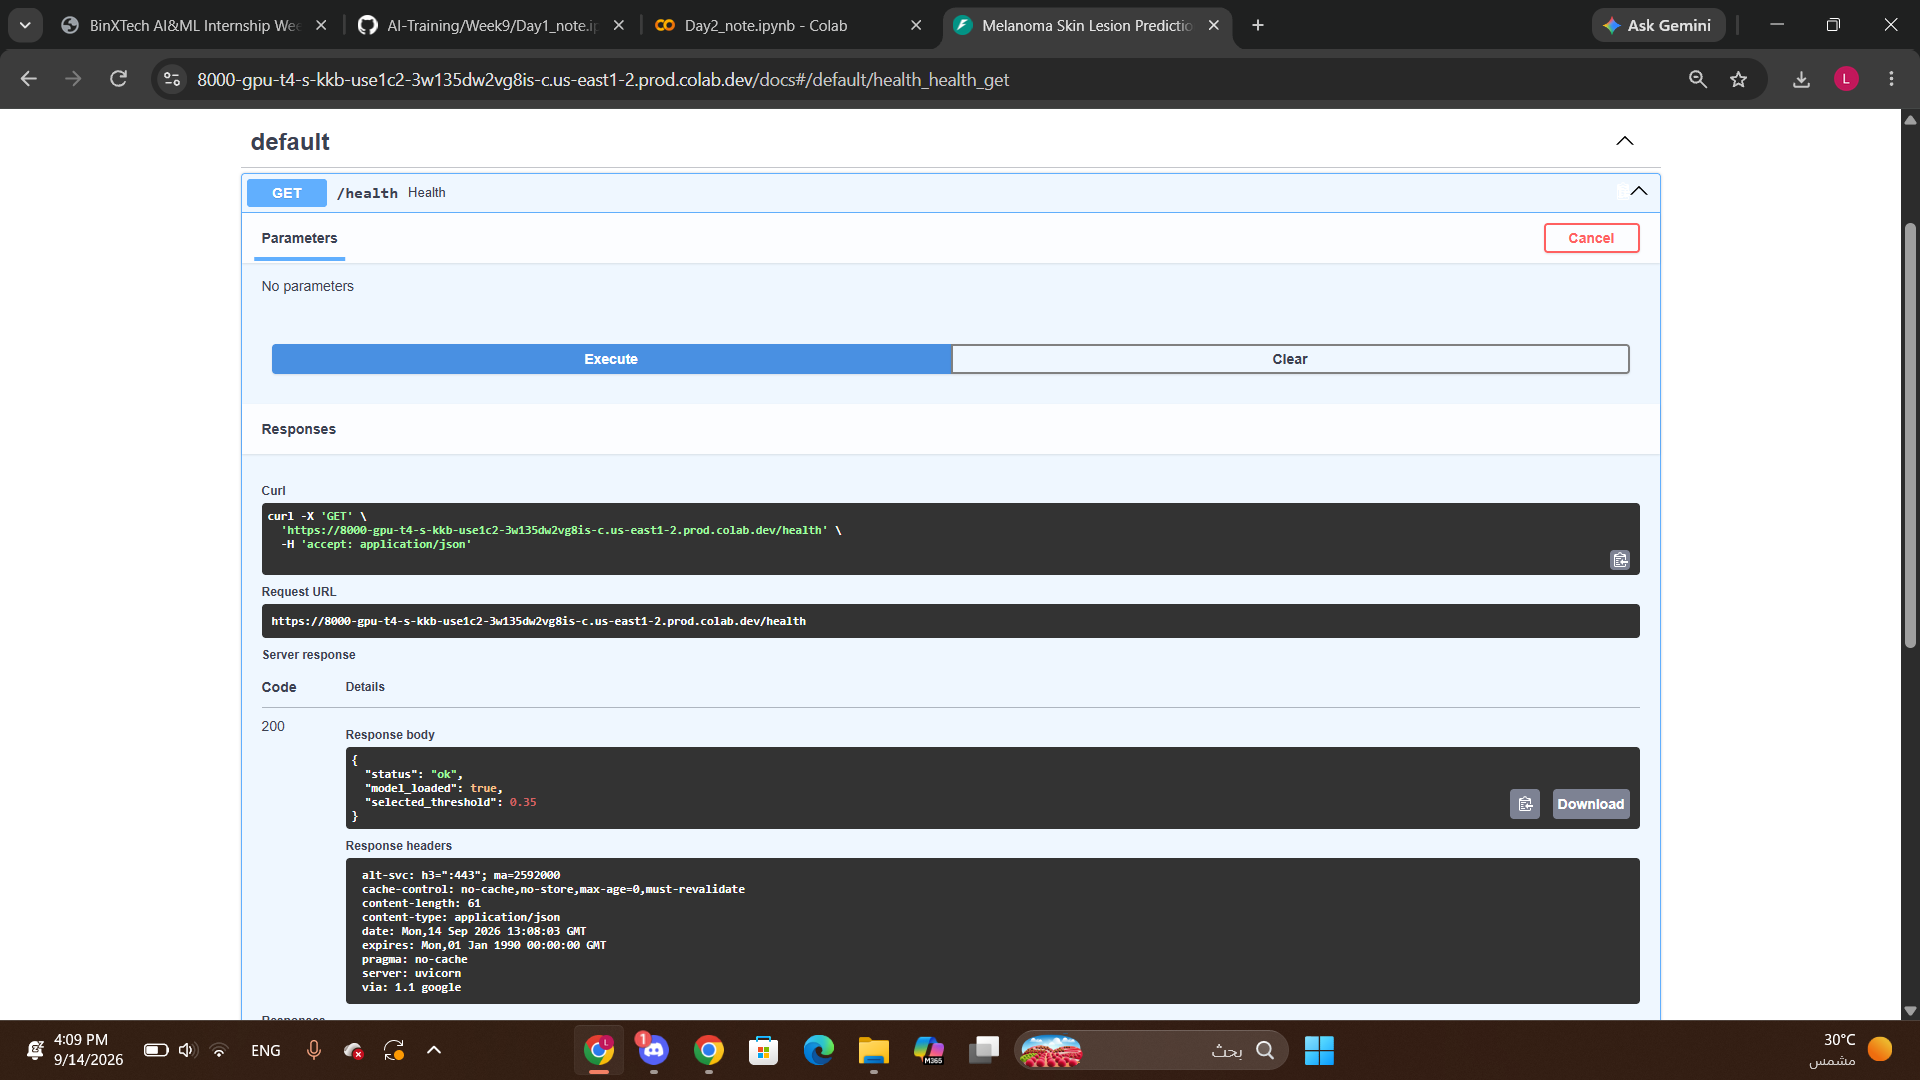

## 2. Valid Image Prediction

The `/predict` endpoint successfully classified the test image.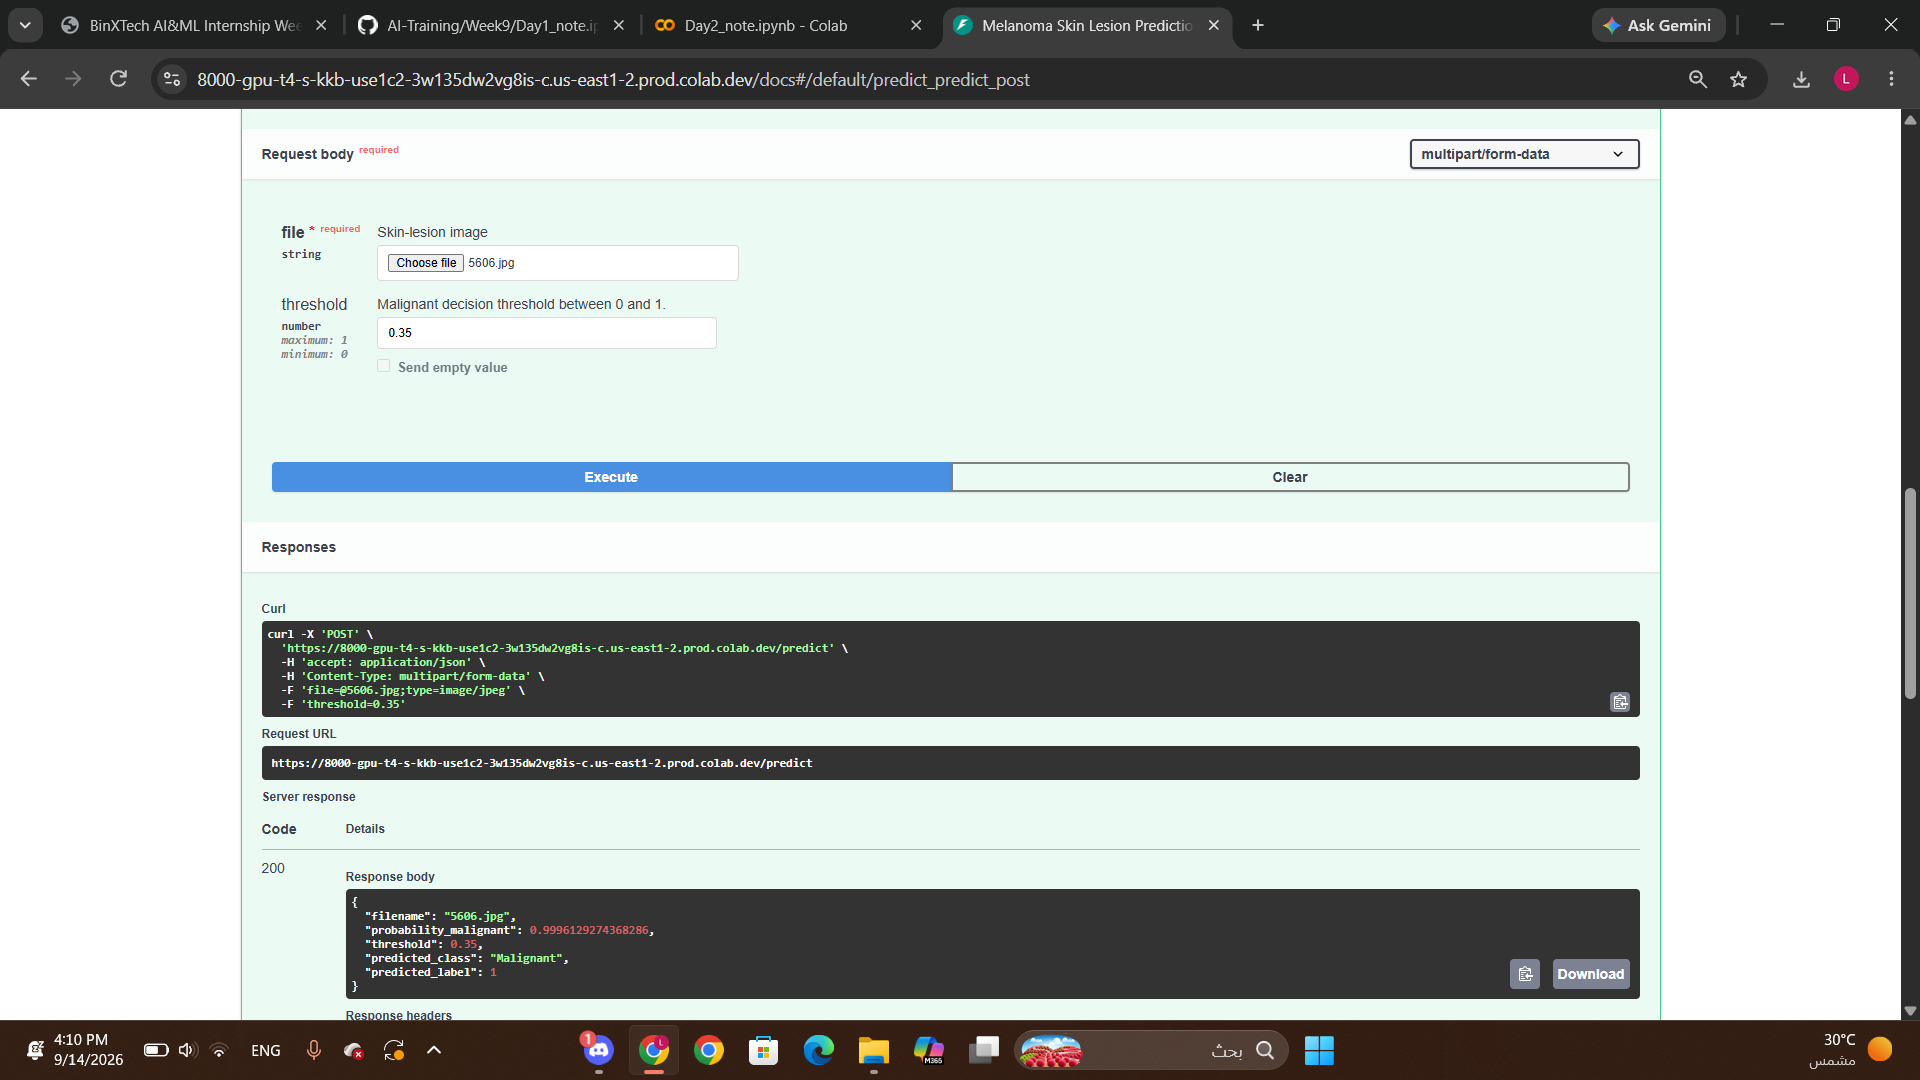

## 3. Invalid File Type

The API correctly rejected an unsupported file type with HTTP 415.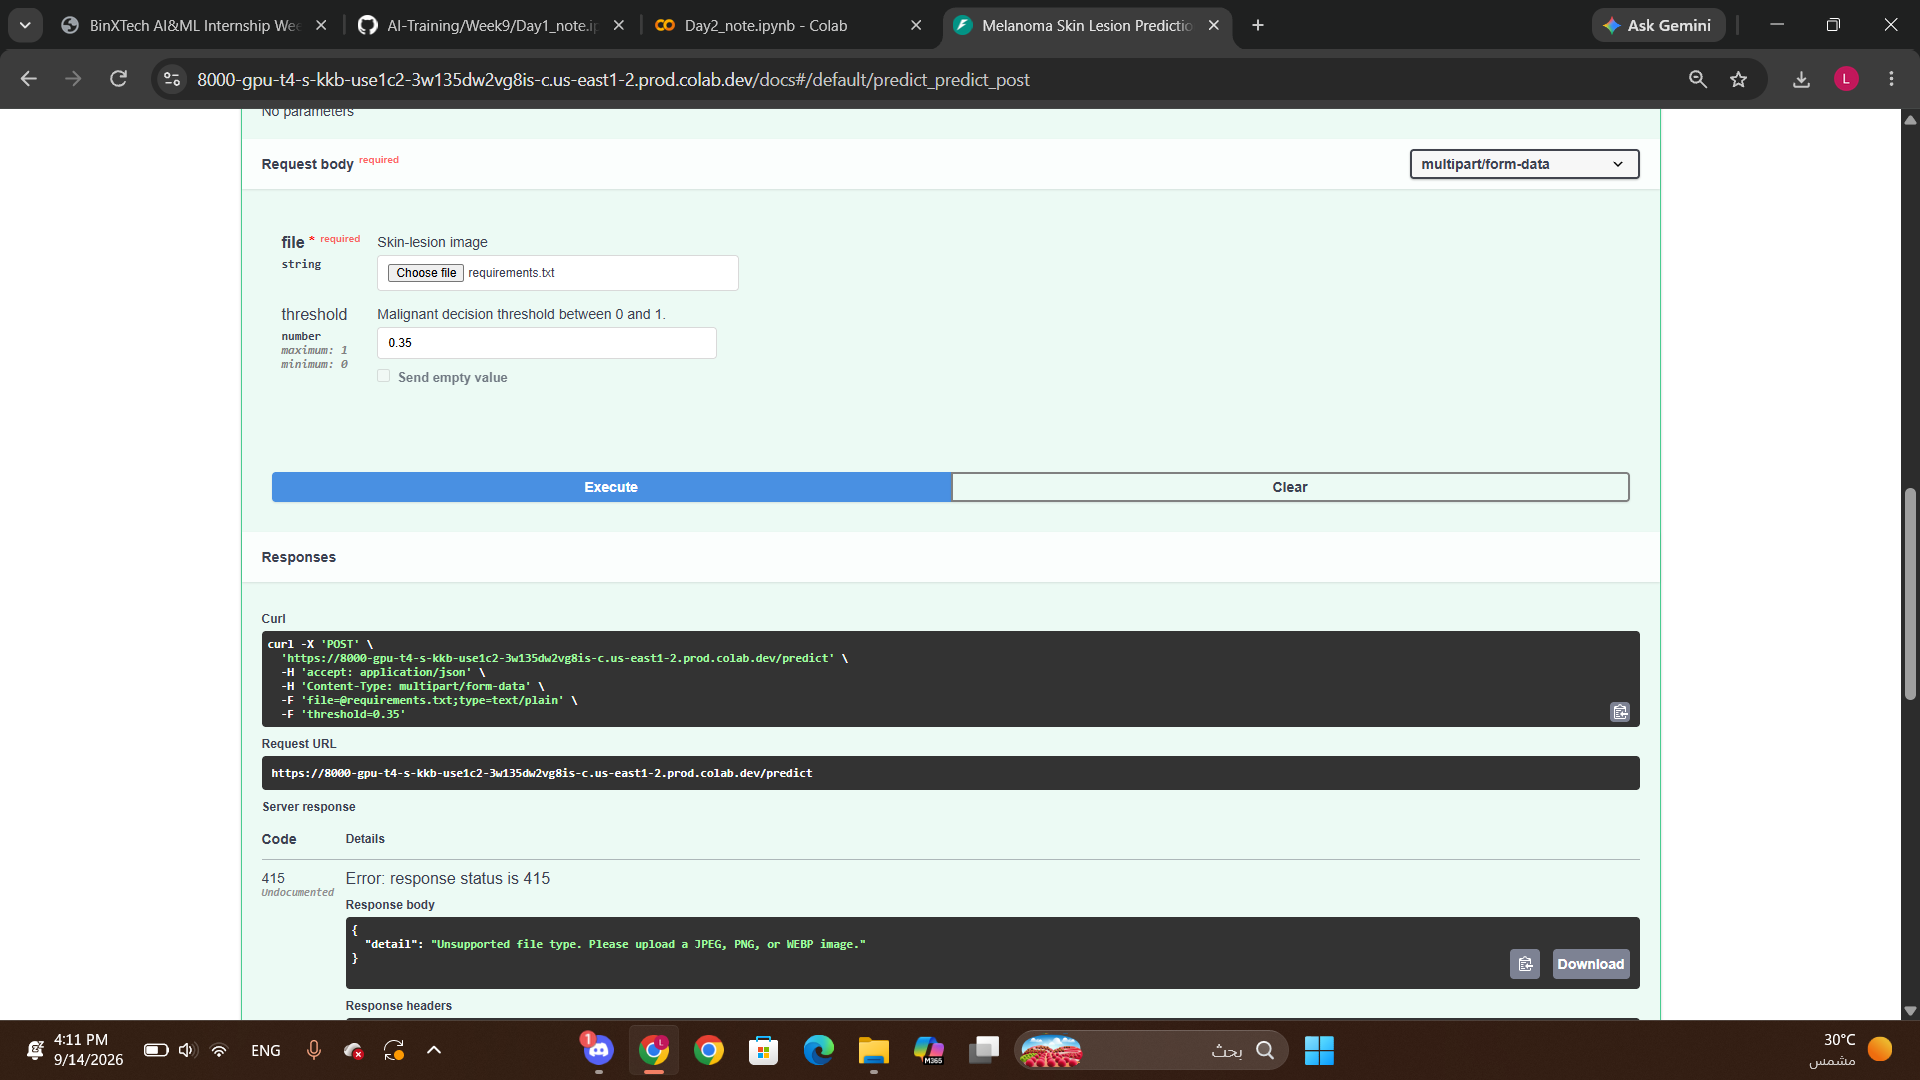

## 4. Invalid Threshold

The API correctly rejected an invalid threshold with HTTP 422.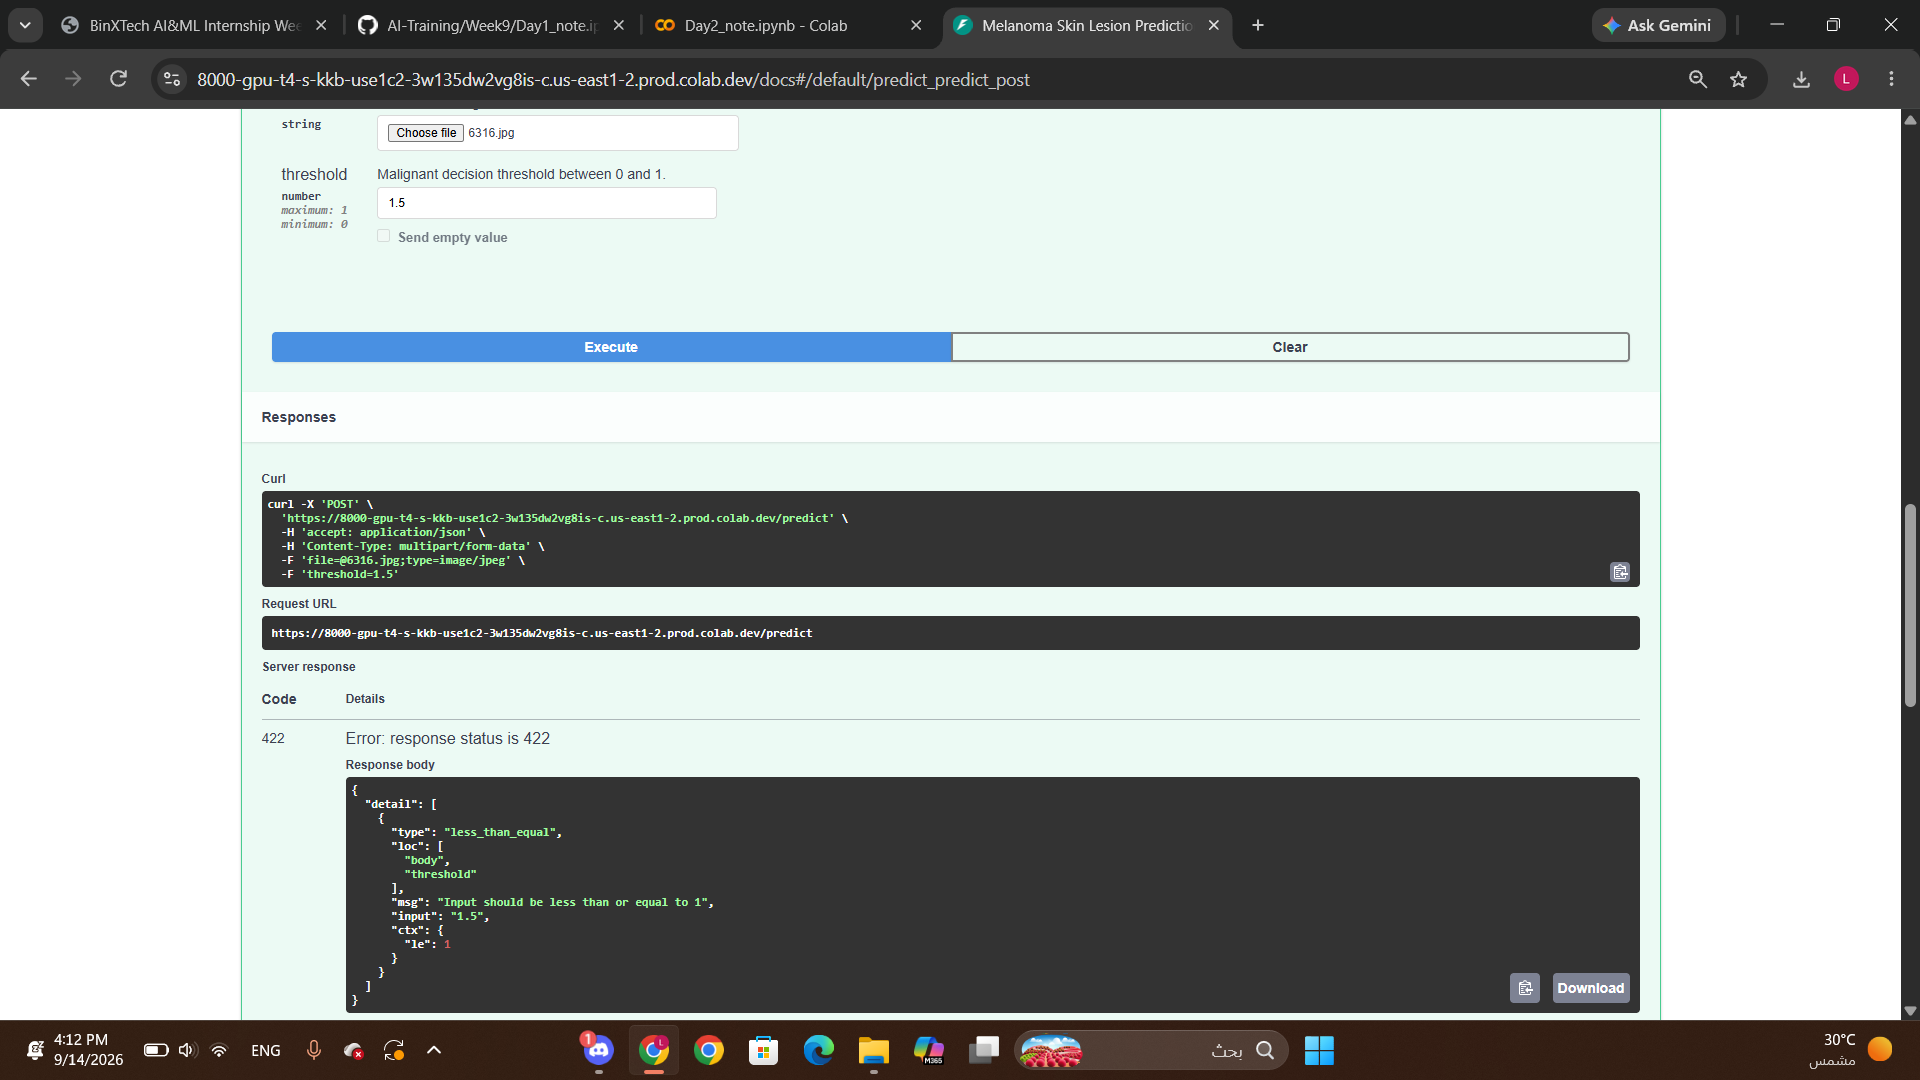

#  Day 2 Validation Checklist

### FastAPI

- [x] FastAPI application created.
- [x] `/predict` POST endpoint created.
- [x] `/health` endpoint created.
- [x] Uvicorn command documented.

### Model Serving

- [x] Saved Week 8 CNN loaded.
- [x] Model is not retrained in the API.
- [x] Input shape verified.
- [x] Selected threshold loaded from Day 1 metadata.

### Preprocessing

- [x] OpenCV image decoding.
- [x] BGR → RGB.
- [x] Resize to 128 × 128.
- [x] float32 conversion.
- [x] `/255.0` normalization.
- [x] Batch dimension added.

### Validation

- [x] Image content type checked.
- [x] Empty files rejected.
- [x] Unreadable images rejected.
- [x] Threshold constrained to 0–1.
- [x] Pydantic response schema defined.
- [x] Invalid input tested.

### Testing

- [x] FastAPI TestClient test included.
- [x] `/docs` testing procedure documented.
- [x] Valid image test included.
- [x] Invalid file test included.
- [x] Invalid threshold test included.


# Day 2 Conclusion

Day 2 successfully moves the Week 8 melanoma CNN from a notebook-only model toward a deployable service.

The trained model remains unchanged. FastAPI acts as the serving layer around it.

The final architecture is:

```text
                    Day 1
        ┌───────────────────────────┐
        │ Serialized CNN            │
        │ Deployment Metadata       │
        │ Preprocessing Contract    │
        │ Selected Threshold = 0.35 │
        └─────────────┬─────────────┘
                      ↓
                    Day 2
        ┌───────────────────────────┐
        │ FastAPI                   │
        │                           │
        │ POST /predict             │
        │ Validation                │
        │ Preprocessing             │
        │ CNN inference             │
        │ Threshold decision        │
        │ JSON response             │
        └─────────────┬─────────────┘
                      ↓
              Frontend / Client
```

Day 1 prepared the model for deployment. Day 2 exposes that model through a FastAPI prediction API while preserving the exact preprocessing and decision threshold used during validation.
